In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# %% Imports
import torch
import torch.nn as nn
import torch.utils.data  # <-- Add this explicit import here!
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import copy
import pandas as pd


# Set GPU device
print(torch.cuda.is_available())
device = torch.device("cuda:0")

True


In [4]:
# %% Load data
TRAIN_ROOT = "/content/drive/MyDrive/data/brain_mri/training"
TEST_ROOT = "/content/drive/MyDrive/data/brain_mri/testing"
train_dataset = torchvision.datasets.ImageFolder(root=TRAIN_ROOT)
test_dataset = torchvision.datasets.ImageFolder(root=TRAIN_ROOT)


In [5]:
# %% Building the model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.vgg16 = models.vgg16(pretrained=True)

        # Replace output layer according to our problem
        in_feats = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_feats, 4)

    def forward(self, x):
        x = self.vgg16(x)
        return x

model = CNNModel()
model.to(device)
print(model)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 57.8MB/s]


CNNModel(
  (vgg16): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16):

In [6]:
# %% Prepare data for pretrained model
train_dataset = torchvision.datasets.ImageFolder(
        root=TRAIN_ROOT,
        transform=transforms.Compose([
                      transforms.Resize((255,255)),
                      transforms.ToTensor()
        ])
)

test_dataset = torchvision.datasets.ImageFolder(
        root=TEST_ROOT,
        transform=transforms.Compose([
                      transforms.Resize((255,255)),
                      transforms.ToTensor()
        ])
)

#train_dataset[0][0].permute(1,2,0)

In [7]:
# %% Create data loaders
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True
)


In [8]:
# %% Train
cross_entropy_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)
epochs = 10

# Iterate x epochs over the train data
for epoch in range(epochs):
    for i, batch in enumerate(train_loader, 0):
        inputs, labels = batch
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        # Labels are automatically one-hot-encoded
        loss = cross_entropy_loss(outputs, labels)
        loss.backward()
        optimizer.step()
        print(loss)

tensor(1.3471, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.3038, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2548, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.3553, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2924, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2730, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2394, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2251, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.1957, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2823, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2534, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2155, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2990, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2514, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.0665, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.1695, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.3364, device='cuda:0', grad_fn=

In [9]:
# %% Inspect predictions for first batch
import pandas as pd
inputs, labels = next(iter(test_loader))
inputs = inputs.to(device)
labels = labels.numpy()
outputs = model(inputs).max(1).indices.detach().cpu().numpy()
comparison = pd.DataFrame()
print("Batch accuracy: ", (labels==outputs).sum()/len(labels))
comparison["labels"] = labels

comparison["outputs"] = outputs
print(comparison)


Batch accuracy:  0.71875
    labels  outputs
0        0        1
1        2        2
2        2        2
3        2        2
4        2        2
5        1        1
6        3        3
7        0        0
8        0        1
9        3        3
10       0        0
11       1        1
12       2        2
13       3        3
14       1        1
15       2        2
16       3        2
17       0        2
18       2        2
19       0        1
20       2        2
21       2        2
22       3        3
23       3        3
24       3        3
25       2        2
26       0        1
27       0        1
28       0        1
29       0        1
30       1        1
31       1        1


In [ ]:
# %% Layerwise relevance propagation for VGG16
# For other CNN architectures this code might become more complex
# Source: https://git.tu-berlin.de/gmontavon/lrp-tutorial
# http://iphome.hhi.de/samek/pdf/MonXAI19.pdf


def apply_lrp_on_vgg16(model, image):
    image = torch.unsqueeze(image, 0) # Shape: [1, 3, 255, 255]

    # >>> Step 1: Extract layers
    layers = list(model.vgg16._modules['features']) \
                + [model.vgg16._modules['avgpool']] \
                + dense_to_conv(list(model.vgg16._modules['classifier']))
    linear_layer_indices = get_linear_layer_indices(model)

    # >>> Step 2: Propagate image through layers
    n_layers = len(layers)
    activations = [image]

    for layer in range(n_layers):
        current_activation = activations[layer]

        # Forward reshape handling for layer 32
        if layer in linear_layer_indices and layer == 32:
            flat_dim = current_activation.shape[1] # 25088
            spatial_dim = int((flat_dim / 512) ** 0.5) # e.g., 7
            current_activation = current_activation.reshape((1, 512, spatial_dim, spatial_dim))

        activation = layers[layer].forward(current_activation)

        if isinstance(layers[layer], torch.nn.modules.pooling.AdaptiveAvgPool2d):
            activation = torch.flatten(activation, start_dim=1)
        activations.append(activation)

    # >>> Step 3: Replace last layer with type-safe one-hot-encoding
    output_activation = activations[-1].detach().cpu().squeeze().numpy()
    max_idx = output_activation.argmax()

    one_hot_output = [float(val) if i == max_idx else 0.0 for i, val in enumerate(output_activation)]
    activations[-1] = torch.FloatTensor([one_hot_output]).to(device)

    # >>> Step 4: Backpropagate relevance scores
    relevances = [torch.zeros_like(act) for act in activations]
    relevances[-1] = activations[-1]

    for layer in range(0, n_layers)[::-1]:
        current = layers[layer]
        if isinstance(current, torch.nn.MaxPool2d):
            layers[layer] = torch.nn.AvgPool2d(2)
            current = layers[layer]

        if isinstance(current, (nn.Conv2d, nn.AvgPool2d, nn.Linear)):
            # FIX: Ensure layer 32 activation is reshaped to 4D spatial grid during backpropagation loop
            if layer in linear_layer_indices and layer == 32:
                flat_dim = activations[layer].shape[1]
                spatial_dim = int((flat_dim / 512) ** 0.5)
                activations[layer] = activations[layer].reshape((1, 512, spatial_dim, spatial_dim))
                # Also ensure the corresponding relevance allocation structure mirrors the 4D canvas
                if relevances[layer+1].dim() == 2:
                    relevances[layer+1] = relevances[layer+1].reshape((1, 512, spatial_dim, spatial_dim))

            activations[layer] = activations[layer].data.requires_grad_(True)

            rho = lambda p: p
            incr = lambda z: z + 1e-9

            if layer <= 16:
                rho = lambda p: p + 0.25 * p.clamp(min=0)
                incr = lambda z: z + 1e-9
            elif 17 <= layer <= 30:
                rho = lambda p: p
                incr = lambda z: z + 1e-9 + 0.25 * ((z**2).mean()**.5).data
            elif layer >= 31:
                rho = lambda p: p
                incr = lambda z: z + 1e-9

            z = incr(new_layer(layers[layer], rho).forward(activations[layer]))
            s = (relevances[layer+1] / z).data

            (z * s).sum().backward()

            grad_val = activations[layer].grad
            c = grad_val if grad_val is not None else torch.zeros_like(activations[layer])
            relevances[layer] = (activations[layer] * c).data
        else:
            relevances[layer] = relevances[layer+1]

    # Return the target input layer pixel matrix explicitly [0]
    return relevances[0]


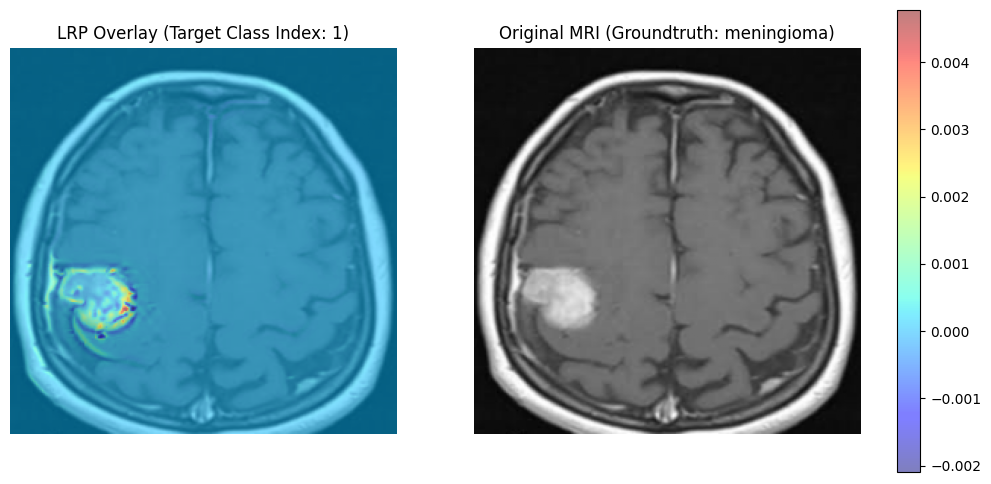

In [25]:
# %% Relevances Visualization
image_id = 11

# 1. Dynamically find the target index based on the true label of this specific image
# This ensures it matches 'meningioma_tumor' (index 1) instead of hardcoding 0!
true_label_idx = labels[image_id]

# 2. Call the fixed LRP tracker with the correct target category
pixel_relevances = apply_lrp_on_vgg16(model, inputs[image_id])

# 3. Format the 4D tensor matrix down to a 2D plot matrix
heatmap = pixel_relevances.squeeze().permute(1, 2, 0).detach().cpu().numpy()
heatmap = heatmap.mean(axis=2) # Collapse channels into intensity

# 4. Get the original MRI image values for the background
original_mri = inputs[image_id].permute(1, 2, 0).detach().cpu().numpy()

# 5. Render side-by-side with an improved overlay
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left Plot: Heatmap overlay directly on top of the brain structures
axes[0].imshow(original_mri, cmap='gray')
# alpha=0.5 lets you see the tumor beneath the red hot spots
im = axes[0].imshow(heatmap, cmap='jet', alpha=0.5)
axes[0].set_title(f"LRP Overlay (Target Class Index: {true_label_idx})")
axes[0].axis('off')

# Right Plot: Clean reference MRI image
axes[1].imshow(original_mri, cmap='gray')
axes[1].set_title(f"Original MRI (Groundtruth: meningioma)")
axes[1].axis('off')

plt.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
plt.show()